In [ ]:
#Dataset 3
from scipy.io import arff
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

#load the ARFF file
df = pd.read_csv('Unicauca-dataset-April-June-2019-Network-flows.csv')
df.dropna(inplace=True)

# Drop rows with NaN or infinite values
df = df.replace([np.inf, -np.inf], np.nan).dropna()
df.drop(['category'], axis=1, inplace=True)
df.drop(['application_protocol'], axis=1, inplace=True)
df.drop([ 'web_service'], axis=1, inplace=True)
df.drop([ 'flow_key'], axis=1, inplace=True)
df.drop(['src_ip'], axis=1, inplace=True)
# Compute frequency of each IP
destination_ip_frequency = df['dst_ip'].value_counts()
df['dst_ip'] = df['dst_ip'].map(destination_ip_frequency)

print(df.describe()) #to summarize statistics
print(df.info()) #to print info about dataset

train, test = train_test_split(df, test_size=0.2, shuffle=True)

       src_ip_numeric      src_port        dst_ip      dst_port         proto  \
count    9.058700e+04  90587.000000  90587.000000  90587.000000  90587.000000   
mean     3.232267e+09  50231.035358  10111.739113   2097.184596     11.159107   
std      1.236658e+02  14852.906508  12331.180496   7525.036699      5.495084   
min      3.232266e+09      0.000000      1.000000      0.000000      1.000000   
25%      3.232267e+09  50072.000000     87.000000     53.000000      6.000000   
50%      3.232267e+09  52912.000000   1505.000000    443.000000      6.000000   
75%      3.232267e+09  58919.500000  28116.000000    443.000000     17.000000   
max      3.232267e+09  65534.000000  28116.000000  65500.000000     17.000000   

       pktTotalCount  octetTotalCount        min_ps        max_ps  \
count   90587.000000     9.058700e+04  90587.000000  90587.000000   
mean       87.991246     1.036044e+05     55.735216   1520.634064   
std      1481.188080     1.815773e+06     55.722308   3780.4171

In [ ]:
#Dataset 3  Naive Bayes CLASSIFIER Minibatch K-Means
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from itertools import product
import numpy as np
from sklearn.cluster import MiniBatchKMeans

k=9
batch_size =100
max_iter=200

minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=max_iter)

priors_list = [
    None,
    [0.1, 0.15, 0.1, 0.15, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.15, 0.15, 0.15, 0.15, 0.15, 0.05, 0.05, 0.05, 0.1],
    [0.1, 0.1, 0.15, 0.15, 0.15, 0.15, 0.1, 0.05, 0.05],
    [0.1, 0.1, 0.1, 0.15, 0.15, 0.15, 0.15, 0.05, 0.05],
    [0.05, 0.05, 0.1, 0.1, 0.15, 0.15, 0.15, 0.15, 0.1]
]


var_smoothing_list = [1e-7, 1e-6]

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for priors, var_smoothing in product(priors_list, var_smoothing_list):
    a += 1
    print(a)

    nb_classifier = GaussianNB(priors=priors, var_smoothing=var_smoothing)
    fold_accuracies = []

    for train_index, test_index in kf.split(train):
        train_labels = minibatch_kmeans.fit_predict(train.iloc[train_index])
        test_labels = minibatch_kmeans.predict(train.iloc[test_index])
        nb_classifier.fit(train.iloc[train_index], train_labels)
        predictions = nb_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)

    mean_accuracy = np.mean(fold_accuracies)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'priors': priors, 'var_smoothing': var_smoothing}

print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)


1


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

2


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

3


...

11


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

12


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

Best hyperparameters: {'priors': [0.1, 0.15, 0.1, 0.15, 0.1, 0.1, 0.1, 0.1, 0.1], 'var_smoothing': 1e-06}
Best accuracy: 0.7547152340897787


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Accuracy of Naive Bayes Classifier with Minibatch K-means cluster labels: 0.7307864720824825
Precision: 0.6137861218303672
Recall: 0.7307864720824825
F1-score: 0.6492372834091827
Confusion Matrix:
 [[16703     0     0     0     0     0     0     0     0]
 [    0     0     0  5076     0     0     0     0     0]
 [    0     0  2100     0     0     0     0     0     0]
 [    0     0     0  8311     0     0     0     0     0]
 [    0     0     0     0  1696     0     0     0     0]
 [    0     0     0     0     0   438     0     0     0]
 [    0     3     0  3208     0     0     0     0     0]
 [    0     0     0     0     0     0     0    96     0]
 [    0     0     0  2523     0     0     0     0     0]]


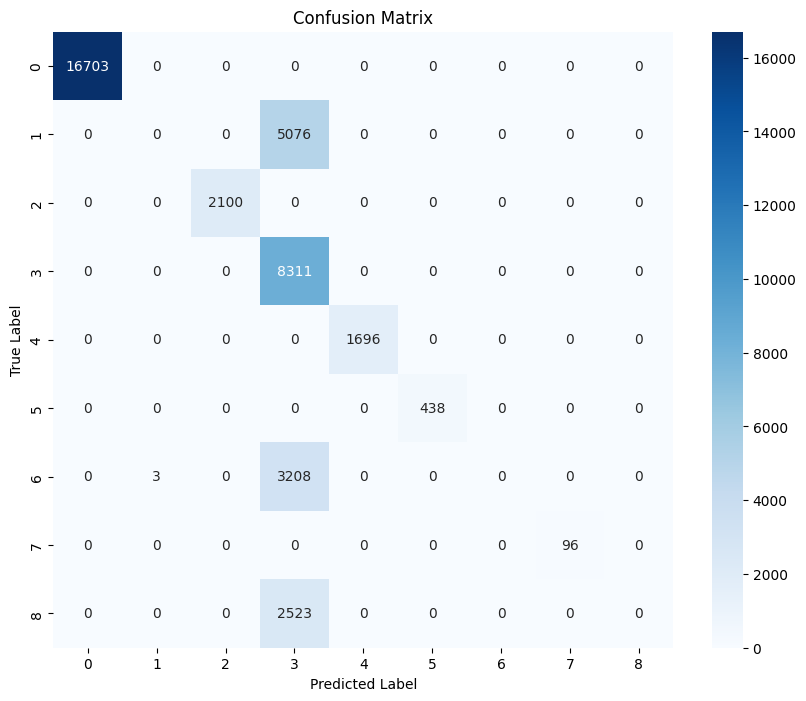

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import MiniBatchKMeans
from sklearn.naive_bayes import GaussianNB

k=9
batch_size =100
max_iter=200

minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=max_iter)

train_labels = minibatch_kmeans.fit_predict(train)
test_labels = minibatch_kmeans.predict(test)


priors= [0.1, 0.15, 0.1, 0.15, 0.1, 0.1, 0.1, 0.1, 0.1]
var_smoothing=1e-06
nb_classifier = GaussianNB(priors=priors, var_smoothing=var_smoothing)

nb_classifier.fit(train, train_labels)

predictions = nb_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of Naive Bayes Classifier with Minibatch K-means cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)
# Define custom class labels
class_labels = np.unique(np.concatenate((test_labels, predictions)))

# Plot heatmap for confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
#Dataset 3  Naive Bayes CLASSIFIER GMM
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from itertools import product
import numpy as np
from sklearn.mixture import GaussianMixture

n_components=10
covariance_type='spherical'

gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, reg_covar=0.1, random_state=42)

priors_list = [
    None,
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
]

var_smoothing_list = [1e-7, 1e-6]

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for priors, var_smoothing in product(priors_list, var_smoothing_list):
    a += 1
    print(a)

    nb_classifier = GaussianNB(priors=priors, var_smoothing=var_smoothing)
    fold_accuracies = []


    for train_index, test_index in kf.split(train):
        train_labels = gmm.fit_predict(train.iloc[train_index])
        test_labels = gmm.predict(train.iloc[test_index])
        nb_classifier.fit(train.iloc[train_index], train_labels)
        predictions = nb_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)

    mean_accuracy = np.mean(fold_accuracies)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'priors': priors, 'var_smoothing': var_smoothing}

print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)


1
2
3
4
5
6
7
8
9
10
11
12
Best hyperparameters: {'priors': [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1], 'var_smoothing': 1e-07}
Best accuracy: 0.9848580328542788


Accuracy of Naive Bayes Classifier with Minibatch GMM cluster labels: 0.956293270907008
Precision: 0.9621581868755126
Recall: 0.956293270907008
F1-score: 0.9540322751666545
Confusion Matrix:
 [[16703     0     0     0     0     0     0     0     0]
 [    0 10540     0     0     0     0     0     0     0]
 [    0     0  2100     0     0     0     0     0     0]
 [    0     0     0    96     0     0     0     0     0]
 [    0     0     0     0  1696     0     0     0     0]
 [    0     0     0     0     0   438     0     0     0]
 [    0  1662     0     0     0     0  4865     0     0]
 [    0     0     0     0     0     0     0  1945     0]
 [    0    57     0     0     0     0    17    19    16]]


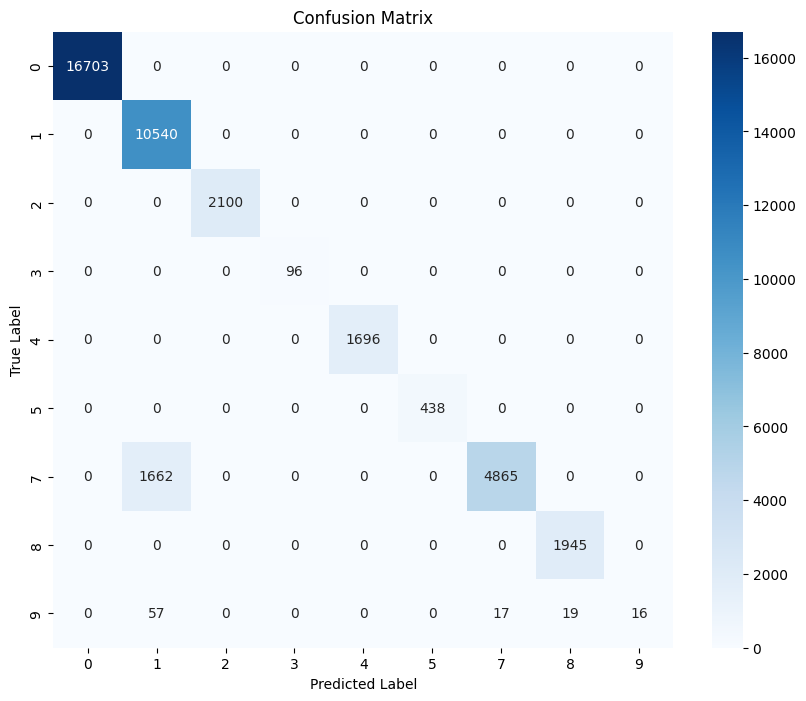

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression


n_components=10
covariance_type='spherical'

gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, reg_covar=0.1, random_state=42)

train_labels = gmm.fit_predict(train)
test_labels =gmm.predict(test)


priors=[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
var_smoothing=1e-07
nb_classifier = GaussianNB(priors=priors, var_smoothing=var_smoothing)

nb_classifier.fit(train, train_labels)

predictions = nb_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of Naive Bayes Classifier with Minibatch GMM cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

class_labels = np.unique(np.concatenate((test_labels, predictions)))

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
#Dataset 3  Naive Bayes CLASSIFIER K-Means
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from itertools import product
import numpy as np
from sklearn.mixture import GaussianMixture


k=10
init_type = 'k-means++'
max_iter=200

kmeans = KMeans(n_clusters=k, random_state=42, max_iter=max_iter, init=init_type)

priors_list = [
    None,
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
]
var_smoothing_list = [1e-7, 1e-6]

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}


a = 0
for priors, var_smoothing in product(priors_list, var_smoothing_list):
    a += 1
    print(a)

    nb_classifier = GaussianNB(priors=priors, var_smoothing=var_smoothing)
    fold_accuracies = []

    for train_index, test_index in kf.split(train):
        train_labels = kmeans.fit_predict(train.iloc[train_index])
        test_labels = kmeans.predict(train.iloc[test_index])
        nb_classifier.fit(train.iloc[train_index], train_labels)
        predictions = nb_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)

    mean_accuracy = np.mean(fold_accuracies)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'priors': priors, 'var_smoothing': var_smoothing}

print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)


1


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

2


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

3


...

11


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

12


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

Best hyperparameters: {'priors': [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1], 'var_smoothing': 1e-07}
Best accuracy: 0.9972854325620242


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Accuracy of Naive Bayes Classifier with K-means cluster labels: 0.9998754794042934
Precision: 0.9998756054396171
Recall: 0.9998754794042934
F1-score: 0.9998630588729533
Confusion Matrix:
 [[16703     0     0     0     0     0     0     0     0]
 [    0  1964     0     0     0     0     0     0     0]
 [    0     0  2100     0     0     0     0     0     0]
 [    0     0     0    96     0     0     0     0     0]
 [    0     0     0     0  1696     0     0     0     0]
 [    0     0     0     0     0   438     0     0     0]
 [    0     0     0     0     0     0 13939     0     0]
 [    0     0     0     0     0     0     1    10     4]
 [    0     0     0     0     0     0     0     0  3203]]


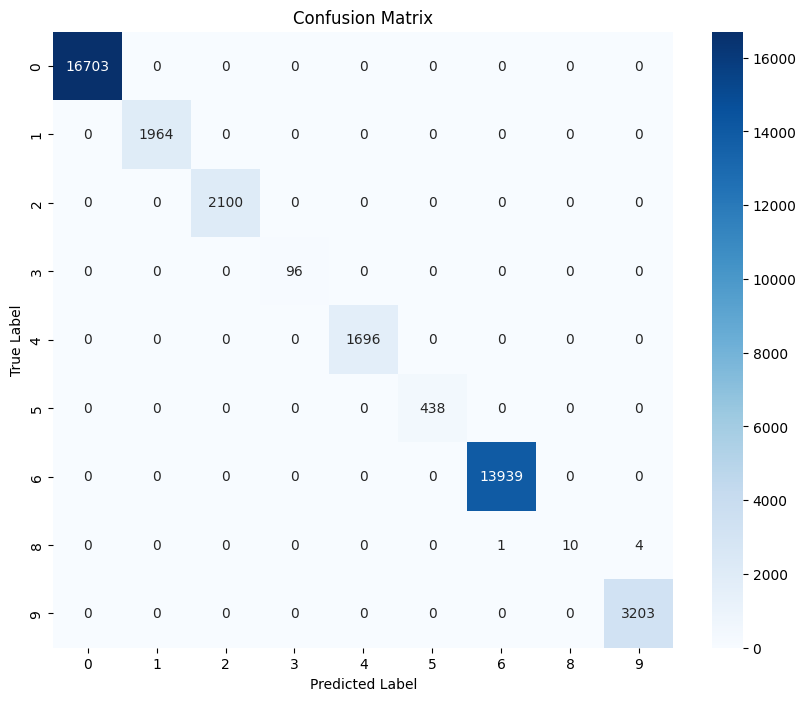

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression

k=10
init_type = 'k-means++'
max_iter=200

kmeans = KMeans(n_clusters=k, random_state=42, max_iter=max_iter, init=init_type)

train_labels = kmeans.fit_predict(train)
test_labels = kmeans.predict(test)

priors=[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
var_smoothing=1e-07
nb_classifier = GaussianNB(priors=priors, var_smoothing=var_smoothing)

nb_classifier.fit(train, train_labels)

predictions = nb_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of Naive Bayes Classifier with K-means cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)
class_labels = np.unique(np.concatenate((test_labels, predictions)))
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
#Datset 3  XGBOOST CLASSIFIER Minibatch K-Means
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import accuracy_score
from sklearn.cluster import MiniBatchKMeans
from itertools import product
import numpy as np

k=9
batch_size =100
max_iter=200

minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=max_iter)

param_grid = {
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 300],
    'gamma': [0.1, 0.2],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
}

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for params in product(*param_grid.values()):
    a += 1
    print(a)

    max_depth, learning_rate, n_estimators, gamma, subsample, colsample_bytree = params

    xgb_classifier = xgb.XGBClassifier(max_depth=max_depth, learning_rate=learning_rate,
                                       n_estimators=n_estimators, gamma=gamma,
                                       subsample=subsample, colsample_bytree=colsample_bytree,
                                       random_state=42)
    fold_accuracies = []

    for train_index, test_index in kf.split(train):
        train_labels = minibatch_kmeans.fit_predict(train.iloc[train_index])
        test_labels = minibatch_kmeans.predict(train.iloc[test_index])
        train_labels -= train_labels.min()
        test_labels -= test_labels.min()
        xgb_classifier.fit(train.iloc[train_index], train_labels)
        predictions = xgb_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)
    mean_accuracy = np.mean(fold_accuracies)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'max_depth': max_depth, 'learning_rate': learning_rate,
                       'n_estimators': n_estimators, 'gamma': gamma,
                       'subsample': subsample, 'colsample_bytree': colsample_bytree}
print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)


1


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

2


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

3


...

15


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

16


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

Best hyperparameters: {'max_depth': 6, 'learning_rate': 0.1, 'n_estimators': 300, 'gamma': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8}
Best accuracy: 0.9987581048986112


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Accuracy of XGBoost Classifier with Minibatch K-means cluster labels: 0.9977370570703168
Precision: 0.9977385392546704
Recall: 0.9977370570703168
F1-score: 0.9977371120288248
Confusion Matrix:
 [[1952    0    0    0    0    0    0    0   16]
 [   0 8496    0    0    0    0    0    0    0]
 [   0    0  817    0    0    0    0    0    0]
 [   0    0    0  588    0    0    0    0    0]
 [   0    0    0    0  133    0    0    0    0]
 [   0    0    0    0    0   38    0    0    0]
 [   0    0    0    0    0    0 1476    0    0]
 [   0    0    0    0    0    0    0 1399    9]
 [  10    0    0    0    0    0    0    6 3178]]


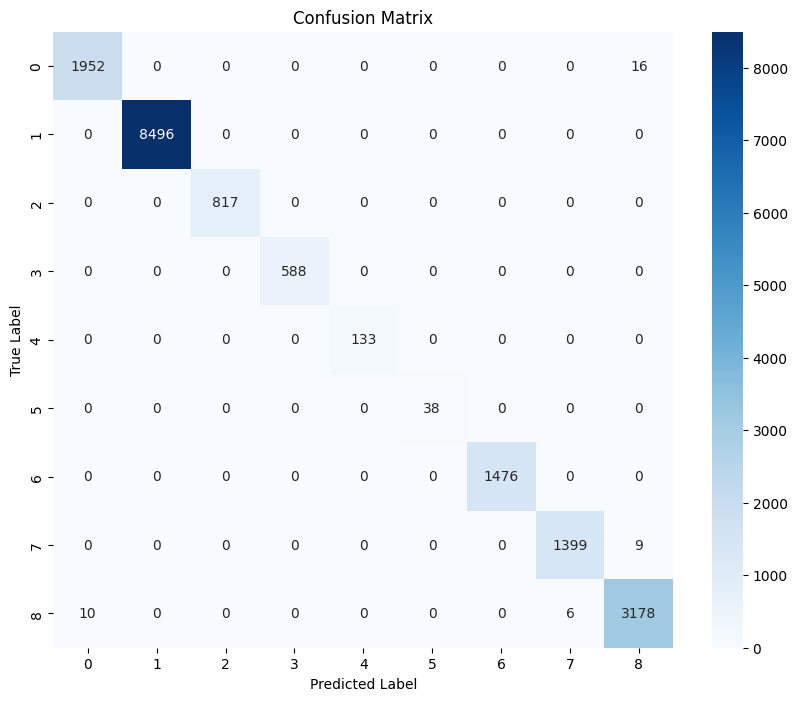

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import xgboost as xgb
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import MiniBatchKMeans

k=9
batch_size =100
max_iter=200

minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=max_iter)

train_labels = minibatch_kmeans.fit_predict(train)
test_labels = minibatch_kmeans.predict(test)

max_depth=6
learning_rate=0.1
n_estimators=300
gamma=0.1
subsample= 0.8
colsample_bytree=0.8

xgb_classifier = xgb.XGBClassifier(max_depth=max_depth, learning_rate=learning_rate,
                                       n_estimators=n_estimators, gamma=gamma,
                                       subsample=subsample, colsample_bytree=colsample_bytree,
                                       random_state=42)

xgb_classifier.fit(train, train_labels)
predictions = xgb_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of XGBoost Classifier with Minibatch K-means cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

class_labels = np.unique(np.concatenate((test_labels, predictions)))
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
#Datset 3  XGBOOST CLASSIFIER K-Means
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import accuracy_score
from sklearn.cluster import MiniBatchKMeans
from itertools import product
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans


k=10
init_type = 'k-means++'
max_iter=200

kmeans = KMeans(n_clusters=k, random_state=42, max_iter=max_iter, init=init_type)

param_grid = {
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 300],
    'gamma': [0.1, 0.2],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
}

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for params in product(*param_grid.values()):
    a += 1
    print(a)

    max_depth, learning_rate, n_estimators, gamma, subsample, colsample_bytree = params

    xgb_classifier = xgb.XGBClassifier(max_depth=max_depth, learning_rate=learning_rate,
                                       n_estimators=n_estimators, gamma=gamma,
                                       subsample=subsample, colsample_bytree=colsample_bytree,
                                       random_state=42)
    fold_accuracies = []

    for train_index, test_index in kf.split(train):
        train_labels = kmeans.fit_predict(train.iloc[train_index])
        test_labels = kmeans.predict(train.iloc[test_index])
        xgb_classifier.fit(train.iloc[train_index], train_labels)
        predictions = xgb_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)
    mean_accuracy = np.mean(fold_accuracies)
    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'max_depth': max_depth, 'learning_rate': learning_rate,
                       'n_estimators': n_estimators, 'gamma': gamma,
                       'subsample': subsample, 'colsample_bytree': colsample_bytree}
print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)


1


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

2


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

3


...

15


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

16


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

Best hyperparameters: {'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 300, 'gamma': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8}
Best accuracy: 0.9987856863394823


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Accuracy of XGBoost Classifier with K-means cluster labels: 0.9990617065901314
Precision: 0.9990632209667664
Recall: 0.9990617065901314
F1-score: 0.9990619817726207
Confusion Matrix:
 [[ 588    0    0    0    0    0    0    0    0]
 [   0 2256    0    0    0    0    5    0    0]
 [   0    0  817    0    0    0    0    0    0]
 [   0    0    0   38    0    0    0    0    0]
 [   0    0    0    0 8496    0    0    0    0]
 [   0    0    0    0    0  133    0    0    0]
 [   0   12    0    0    0    0 3641    0    0]
 [   0    0    0    0    0    0    0  656    0]
 [   0    0    0    0    0    0    0    0 1476]]


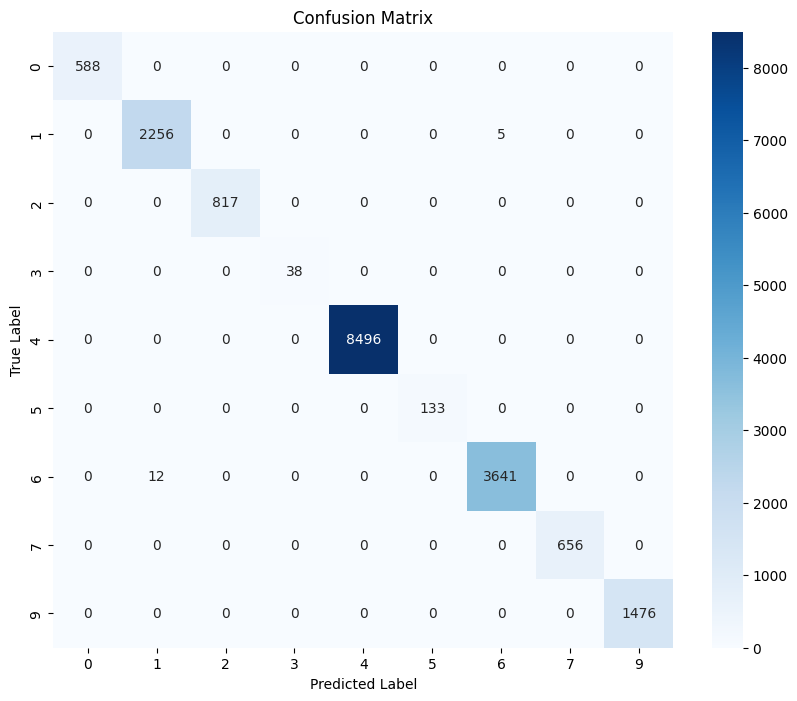

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression

k=10
init_type = 'k-means++'
max_iter=200

kmeans = KMeans(n_clusters=k, random_state=42, max_iter=max_iter, init=init_type)

train_labels = kmeans.fit_predict(train)
test_labels = kmeans.predict(test)

max_depth=3
learning_rate=0.1
n_estimators=300
gamma=0.1
subsample= 0.8
colsample_bytree=0.8

xgb_classifier = xgb.XGBClassifier(max_depth=max_depth, learning_rate=learning_rate,
                                       n_estimators=n_estimators, gamma=gamma,
                                       subsample=subsample, colsample_bytree=colsample_bytree,
                                       random_state=42)


xgb_classifier.fit(train, train_labels)


predictions = xgb_classifier.predict(test)


accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of XGBoost Classifier with K-means cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

class_labels = np.unique(np.concatenate((test_labels, predictions)))

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
#Datset 3  XGBOOST CLASSIFIER GMM
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import accuracy_score
from sklearn.cluster import MiniBatchKMeans
from itertools import product
import numpy as np
from sklearn.mixture import GaussianMixture

n_components=10
covariance_type='spherical'

gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, reg_covar=0.1, random_state=42)

param_grid = {
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 300],
    'gamma': [0.1, 0.2],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
}

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for params in product(*param_grid.values()):
    a += 1
    print(a)

    max_depth, learning_rate, n_estimators, gamma, subsample, colsample_bytree = params


    xgb_classifier = xgb.XGBClassifier(max_depth=max_depth, learning_rate=learning_rate,
                                       n_estimators=n_estimators, gamma=gamma,
                                       subsample=subsample, colsample_bytree=colsample_bytree,
                                       random_state=42)
    fold_accuracies = []


    for train_index, test_index in kf.split(train):
        train_labels = gmm.fit_predict(train.iloc[train_index])
        test_labels = gmm.predict(train.iloc[test_index])
        xgb_classifier.fit(train.iloc[train_index], train_labels)
        predictions = xgb_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)

    mean_accuracy = np.mean(fold_accuracies)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'max_depth': max_depth, 'learning_rate': learning_rate,
                       'n_estimators': n_estimators, 'gamma': gamma,
                       'subsample': subsample, 'colsample_bytree': colsample_bytree}

print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
Best hyperparameters: {'max_depth': 6, 'learning_rate': 0.1, 'n_estimators': 100, 'gamma': 0.2, 'subsample': 0.8, 'colsample_bytree': 0.8}
Best accuracy: 0.9986890889337564


Accuracy of XGBoost Classifier with GMM cluster labels: 0.9987305442101777
Precision: 0.9987334871855735
Recall: 0.9987305442101777
F1-score: 0.998730561377533
Confusion Matrix:
 [[2149    0    0    0    0    0    4    1    0    0]
 [   0 8496    0    0    0    0    0    0    0    0]
 [   0    0  817    0    0    0    0    0    0    0]
 [   0    0    0   38    0    0    0    0    0    0]
 [   0    0    0    0  588    0    0    0    0    0]
 [   0    0    0    0    0  133    0    0    0    0]
 [  11    0    0    0    0    0 3616    1    0    0]
 [   5    0    0    0    0    0    1  435    0    0]
 [   0    0    0    0    0    0    0    0  647    0]
 [   0    0    0    0    0    0    0    0    0 1176]]


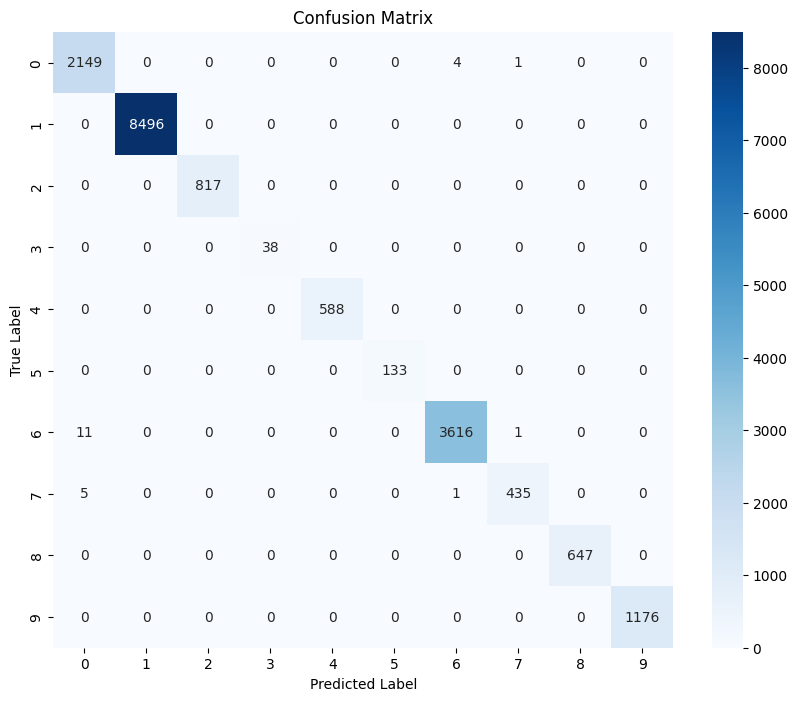

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression

n_components=10
covariance_type='spherical'

gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, reg_covar=0.1, random_state=42)

train_labels = gmm.fit_predict(train)
test_labels = gmm.predict(test)

max_depth=6
learning_rate=0.1
n_estimators=100
gamma=0.2
subsample= 0.8
colsample_bytree=0.8

xgb_classifier = xgb.XGBClassifier(max_depth=max_depth, learning_rate=learning_rate,
                                       n_estimators=n_estimators, gamma=gamma,
                                       subsample=subsample, colsample_bytree=colsample_bytree,
                                       random_state=42)

xgb_classifier.fit(train, train_labels)

predictions = xgb_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of XGBoost Classifier with GMM cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

class_labels = np.unique(np.concatenate((test_labels, predictions)))

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
import pandas as pd

score_data = {
    'Logistic Regression': [0.96543126],
    'Naive Bayes': [0.96792969],
    'Support Vector Machine': [0.99976244],
    'Decision Tree': [0.9973932],
    'Random Forest': [0.998218],
    'AdaBoost': [0.97132495],
    'XGBoost': [0.9988716],
}

df = pd.DataFrame(score_data)
df = df.transpose()
df.columns = ['Score']

print(df)

                           Score
Logistic Regression     0.965431
Naive Bayes             0.967930
Support Vector Machine  0.999762
Decision Tree           0.997393
Random Forest           0.998218
AdaBoost                0.971325
XGBoost                 0.998872


In [ ]:
#Datset 3  RANDOM Forest  GMM
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
import numpy as np
from sklearn.mixture import GaussianMixture

n_components=10
covariance_type='spherical'

gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, reg_covar=0.1, random_state=42)

n_estimators_list = [50, 100]
max_depth_list = [None, 5]
min_samples_split_list = [2, 5]
min_samples_leaf_list = [2, 4]
max_features_list = ['auto']

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}
a=0

for n_estimators in n_estimators_list:
    for max_depth in max_depth_list:
        for min_samples_split in min_samples_split_list:
            for min_samples_leaf in min_samples_leaf_list:
                for max_features in max_features_list:
                    a=a+1
                    print(a)
                    rf_classifier = RandomForestClassifier(n_estimators=n_estimators,
                                                            max_depth=max_depth,
                                                            min_samples_split=min_samples_split,
                                                            min_samples_leaf=min_samples_leaf,
                                                            max_features=max_features,
                                                            random_state=42)
                    fold_accuracies = []

                    for train_index, test_index in kf.split(train):
                        train_labels = gmm.fit_predict(train.iloc[train_index])
                        test_labels = gmm.predict(train.iloc[test_index])
                        rf_classifier.fit(train.iloc[train_index], train_labels)
                        predictions = rf_classifier.predict(train.iloc[test_index])
                        fold_accuracy = accuracy_score(test_labels, predictions)
                        fold_accuracies.append(fold_accuracy)
                    mean_accuracy = np.mean(fold_accuracies)
                    if mean_accuracy > best_accuracy:
                        best_accuracy = mean_accuracy
                        best_params = {'n_estimators': n_estimators,
                                       'max_depth': max_depth,
                                       'min_samples_split': min_samples_split,
                                       'min_samples_leaf': min_samples_leaf,
                                       'max_features': max_features}

print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)

1


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomFor

2


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomFor

3


...

15


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomFor

16


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomFor

Best hyperparameters: {'n_estimators': 50, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'auto'}
Best accuracy: 0.9999880053290611


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


Accuracy of Logistic Regression Classifier with GMM cluster labels: 0.9999931459199375
Precision: 0.9999931460782889
Recall: 0.9999931459199375
F1-score: 0.9999931459391923
Confusion Matrix:
 [[ 23614      0      0      0      0      0      0      0      0      0]
 [     0 119734      0      0      0      0      0      0      0      0]
 [     0      0  13190      0      0      0      0      0      0      0]
 [     0      0      0    529      0      0      0      0      0      0]
 [     0      0      0      0  16392      0      0      0      0      0]
 [     0      0      0      0      0   3717      0      0      0      0]
 [     0      0      0      0      0      0  42134      0      1      0]
 [     0      0      0      0      0      0      0  21641      0      0]
 [     0      0      0      0      0      0      0      1  46909      0]
 [     0      0      0      0      0      0      0      0      0   3935]]


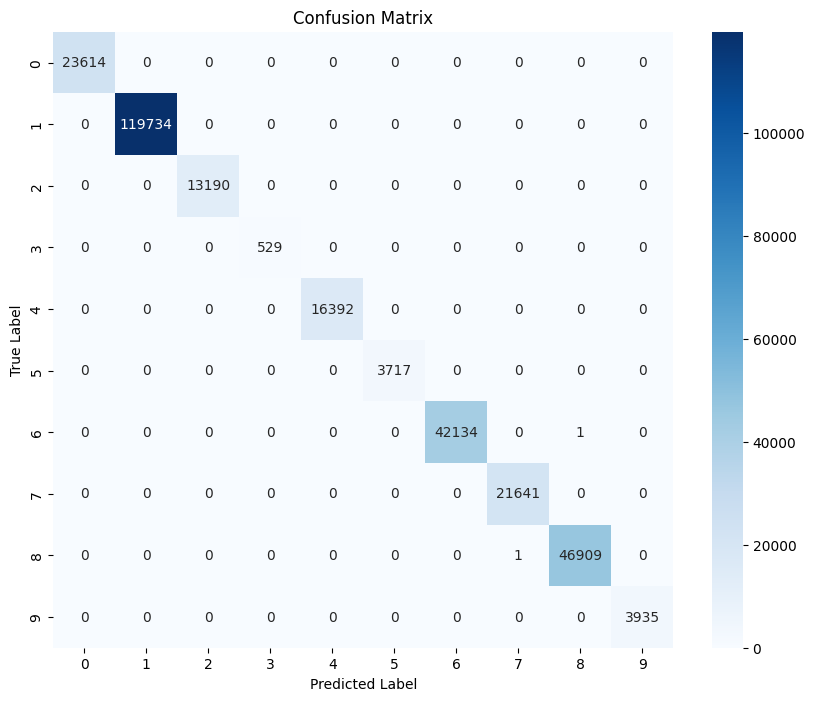

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture

n_components=10
covariance_type='spherical'

gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, reg_covar=0.1, random_state=42)
train_labels = gmm.fit_predict(train)
test_labels = gmm.predict(test)

n_estimators= 50
max_depth= None
min_samples_split= 5
min_samples_leaf= 2
max_features='auto'

rf_classifier = RandomForestClassifier(n_estimators=n_estimators,
                                                            max_depth=max_depth,
                                                            min_samples_split=min_samples_split,
                                                            min_samples_leaf=min_samples_leaf,
                                                            max_features=max_features,
                                                            random_state=42)
rf_classifier.fit(train, train_labels)

predictions = rf_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of Logistic Regression Classifier with GMM cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

class_labels = np.unique(np.concatenate((test_labels, predictions)))

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
